# LDA on Non-Gaussian Dataset
This notebook demonstrates how Linear Discriminant Analysis (LDA) behaves on a non-Gaussian dataset and explains its limitations step by step.

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Step 2: Load the Dataset

In [6]:
data = pd.read_csv('lda_nongaussian.csv')
data.head()
data.describe()

,Feature1,Feature2,Label
count,300.000000,300.000000,300.000000
mean,0.501651,0.262783,0.500000
std,0.896010,0.531950,0.500835
min,-1.472502,-0.911608,0.000000
25%,-0.129955,-0.149315,0.000000
50%,0.475562,0.276462,0.500000
75%,1.111365,0.671292,1.000000
max,2.548764,1.504308,1.000000


## Step 3: Separate Features and Target

In [12]:
# Assume last column is target/class label
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print('Feature Shape:', X.shape)
print('Target Shape:', y.shape)
print('\nClass Labels:')
print(y.unique())

Feature Shape: (300, 2)
Target Shape: (300,)

Class Labels:
[1 0]


## Step 4: Standardize the Features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Standardized Data Shape:', X_scaled.shape)

Standardized Data Shape: (300, 2)


## Step 5: Apply Linear Discriminant Analysis (LDA)
We reduce the dataset into 1 dimension for visualization.

In [7]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

print('LDA Transformed Shape:', X_lda.shape)

LDA Transformed Shape: (300, 1)


## Step 6: Visualize LDA Projection

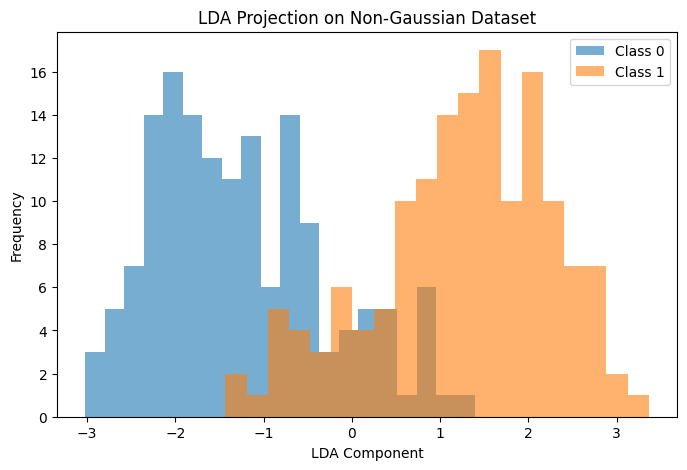

In [8]:
plt.figure(figsize=(8,5))
for cls in np.unique(y):
    plt.hist(X_lda[y == cls], bins=20, alpha=0.6, label=f'Class {cls}')

plt.xlabel('LDA Component')
plt.ylabel('Frequency')
plt.title('LDA Projection on Non-Gaussian Dataset')
plt.legend()
plt.show()

## Step 7: Visualize in 2D using PCA for Comparison

Covariance Matrix:
 [[ 0.80283373 -0.19726942]
 [-0.19726942  0.28297093]]


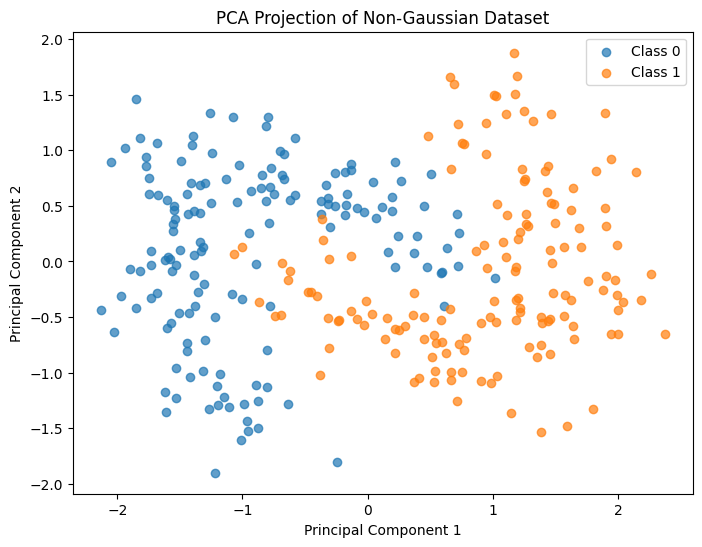

In [13]:


# Covariance matrix
cov_matrix = np.cov(X, rowvar=False)
print("Covariance Matrix:\n", cov_matrix)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for cls in np.unique(y):
    plt.scatter(X_pca[y == cls, 0], X_pca[y == cls, 1], label=f'Class {cls}', alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Non-Gaussian Dataset')
plt.legend()
plt.show()

## Step 8: Compare LDA and PCA

### Question 1: Is class separation as clear as in the Gaussian dataset?
- Usually, class separation is **less clear** in a non-Gaussian dataset.
- LDA works best when classes follow Gaussian distributions.
- Overlapping regions are often visible here.

### Question 2: What assumption of LDA is violated here?
LDA assumes:
1. Data in each class follows a Gaussian (normal) distribution.
2. Classes share the same covariance matrix.

In this dataset, the Gaussian assumption is violated.

### Question 3: How does the shape of the data affect LDA performance?
- Non-linear or irregular class shapes reduce LDA performance.
- LDA creates linear boundaries.
- If data clusters are curved, skewed, or multi-modal, separation becomes difficult.

### Question 4: Would PCA perform better or worse here? Explain.
- PCA may sometimes perform better visually because it captures maximum variance.
- However, PCA does not use class labels.
- LDA uses labels but struggles when Gaussian assumptions fail.
- Therefore:
  - PCA may show cleaner structure.
  - LDA may show weaker class separation.

## Step 9: Conclusion

- LDA performs best on Gaussian and linearly separable data.
- Non-Gaussian distributions reduce its effectiveness.
- PCA can sometimes provide better visualization when LDA assumptions are violated.
- Understanding data distribution is important before choosing dimensionality reduction techniques.